# 01 - Burgers' Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t + u u_x = \nu u_{xx}$, $\nu = 0.01/\pi$

**IC:** $u(x,0) = -\sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

---
### Experiments
1. Vanilla PINN - clean dense data
2. Vanilla PINN - noisy sparse data (ε=0.1, N_ic=20)
3. AC-PINN - clean dense data
4. AC-PINN - noisy sparse data (ε=0.1, N_ic=20)

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    BurgersFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE      = 'burgers'
LAYERS   = [2, 64, 64, 64, 64, 64, 1]
EPOCHS   = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS  = '../results/burgers/'
FIGURES  = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

BurgersFDM solved in 0.5347s


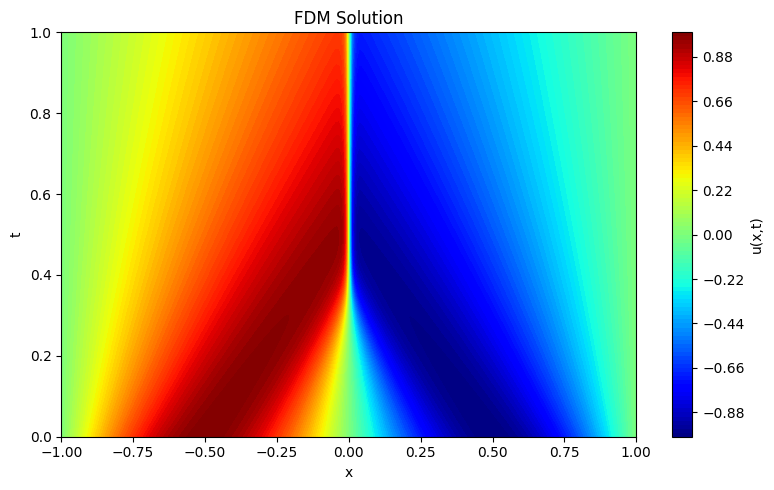

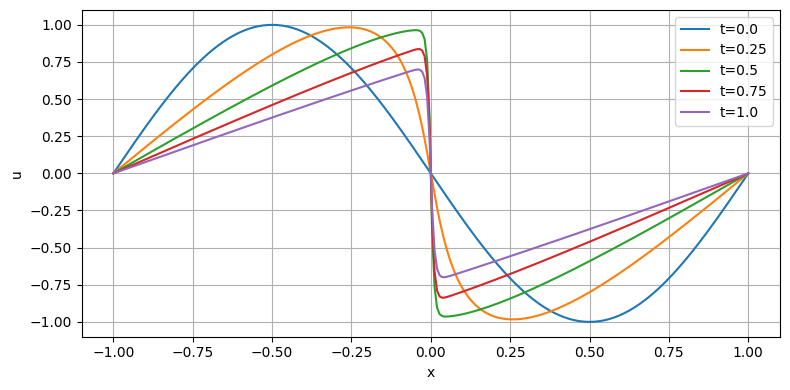

FDM runtime: 0.5347s


In [2]:
fdm = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
fdm.plot_solution()
fdm.plot_time_slices()
print(f'FDM runtime: {fdm.runtime:.4f}s')

## Section 2 - Data Conditions

In [3]:
# Clean dense
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
# Noisy sparse
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)

print('Data conditions ready')
print(f'  Clean dense  : N_ic={data_clean_dense["x_ic"].shape[0]}')
print(f'  Noisy sparse : N_ic={data_noisy_sparse["x_ic"].shape[0]}, eps=0.1')

Data conditions ready
  Clean dense  : N_ic=1000
  Noisy sparse : N_ic=20, eps=0.1


## Section 3 - Experiment 1: Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Burgers | Vanilla Clean | Epoch     0/10000] Total: 0.872319 | IC: 0.333219 | BC: 0.173632 | PDE: 0.073094


[Burgers | Vanilla Clean | Epoch  1000/10000] Total: 0.114410 | IC: 0.096111 | BC: 0.001168 | PDE: 0.003426


[Burgers | Vanilla Clean | Epoch  2000/10000] Total: 0.080533 | IC: 0.061255 | BC: 0.000312 | PDE: 0.003793


[Burgers | Vanilla Clean | Epoch  3000/10000] Total: 0.024959 | IC: 0.018914 | BC: 0.000113 | PDE: 0.001186


...

[Burgers | Vanilla Clean | Epoch  6000/10000] Total: 0.005208 | IC: 0.002621 | BC: 0.000021 | PDE: 0.000513


[Burgers | Vanilla Clean | Epoch  7000/10000] Total: 0.003083 | IC: 0.001996 | BC: 0.000008 | PDE: 0.000216


[Burgers | Vanilla Clean | Epoch  8000/10000] Total: 0.002206 | IC: 0.001344 | BC: 0.000007 | PDE: 0.000171


[Burgers | Vanilla Clean | Epoch  9000/10000] Total: 0.001512 | IC: 0.000815 | BC: 0.000009 | PDE: 0.000138



Training complete in 160.36s


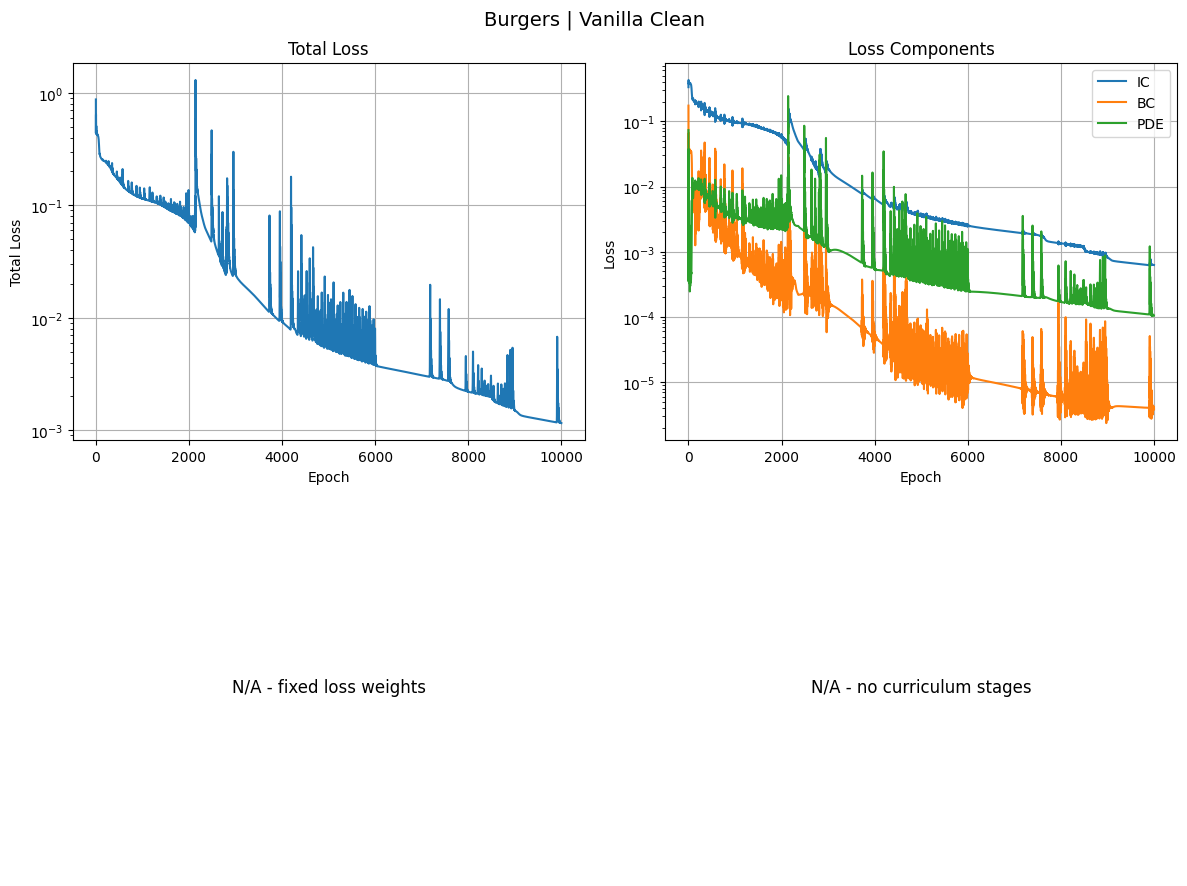

Saved: ../figures/burgers/vanilla_clean_training.png
Saved: ../figures/burgers/vanilla_clean_training.csv


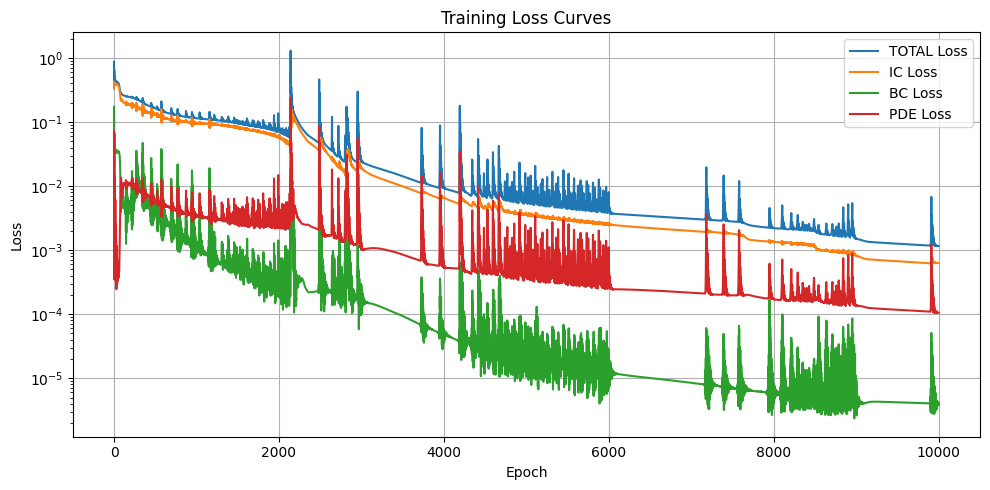

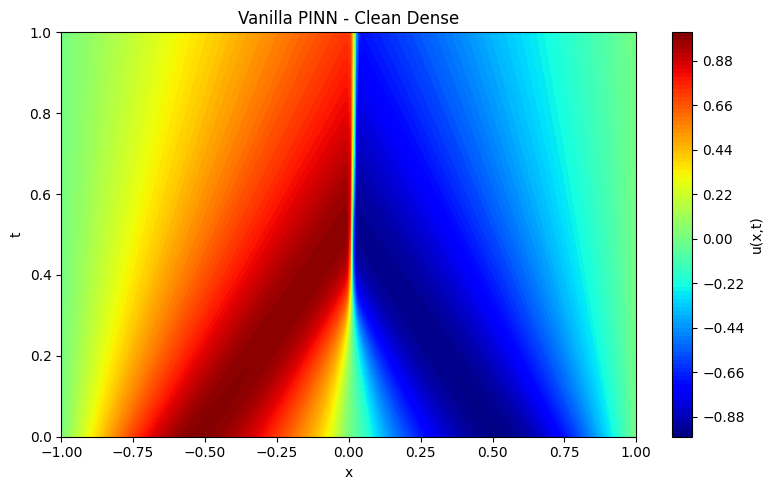

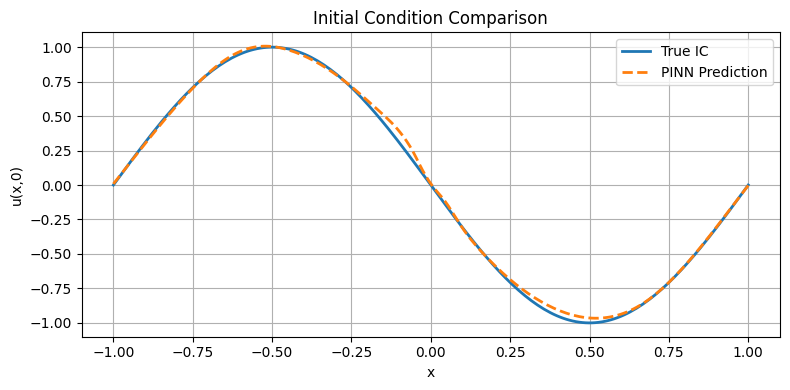

Saved: ../results/burgers/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Burgers | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS + 'vanilla_clean_history.npy')

## Section 4 - Experiment 2: Vanilla PINN, Noisy Sparse

[Burgers | Vanilla Noisy | Epoch     0/10000] Total: 0.677775 | IC: 0.607759 | BC: 0.057484 | PDE: 0.002506


[Burgers | Vanilla Noisy | Epoch  1000/10000] Total: 0.145776 | IC: 0.096295 | BC: 0.023875 | PDE: 0.005121


[Burgers | Vanilla Noisy | Epoch  2000/10000] Total: 0.080294 | IC: 0.032926 | BC: 0.025521 | PDE: 0.004369


[Burgers | Vanilla Noisy | Epoch  3000/10000] Total: 0.051445 | IC: 0.023326 | BC: 0.022830 | PDE: 0.001058


[Burgers | Vanilla Noisy | Epoch  4000/10000] Total: 0.045409 | IC: 0.019153 | BC: 0.022588 | PDE: 0.000733


...

[Burgers | Vanilla Noisy | Epoch  6000/10000] Total: 0.038282 | IC: 0.013411 | BC: 0.021623 | PDE: 0.000650


[Burgers | Vanilla Noisy | Epoch  7000/10000] Total: 0.035793 | IC: 0.012405 | BC: 0.021368 | PDE: 0.000404


[Burgers | Vanilla Noisy | Epoch  8000/10000] Total: 0.034553 | IC: 0.011234 | BC: 0.021020 | PDE: 0.000460


[Burgers | Vanilla Noisy | Epoch  9000/10000] Total: 0.031738 | IC: 0.009187 | BC: 0.020793 | PDE: 0.000351



Training complete in 138.18s


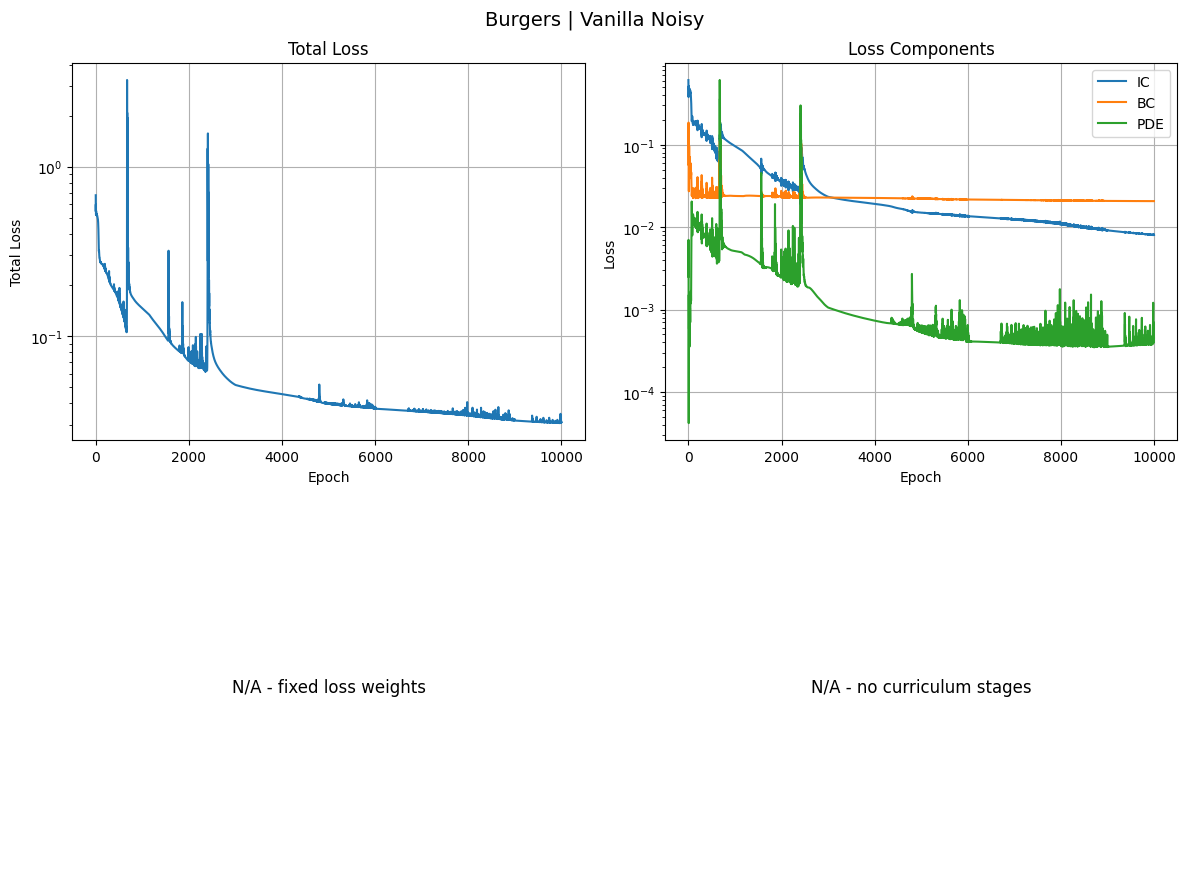

Saved: ../figures/burgers/vanilla_noisy_training.png
Saved: ../figures/burgers/vanilla_noisy_training.csv


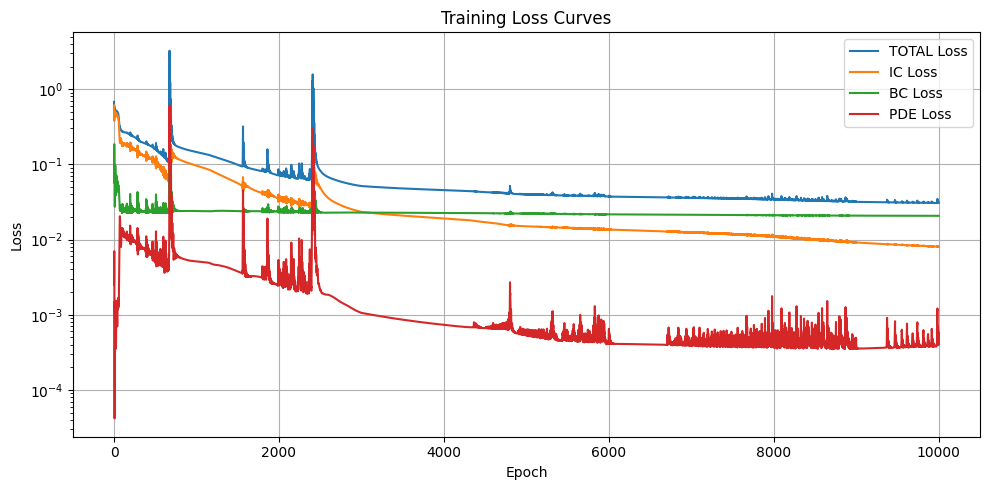

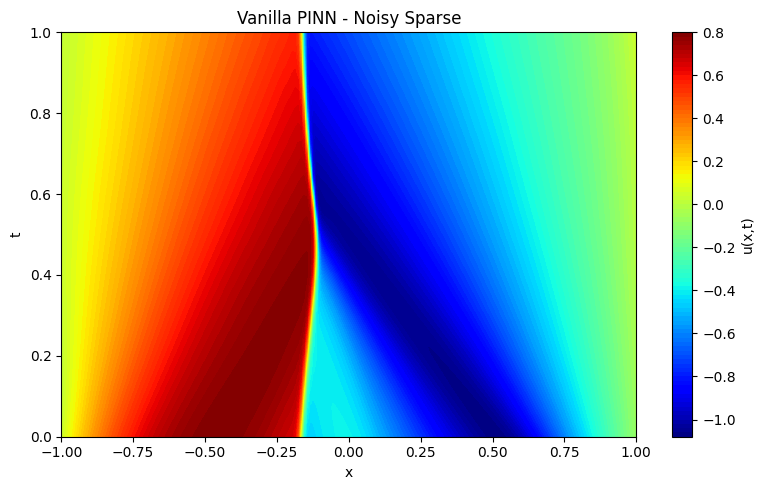

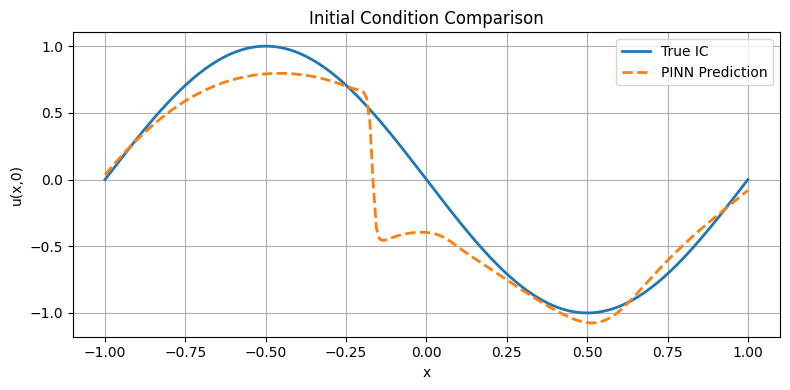

Saved: ../results/burgers/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Burgers | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
vanilla_noisy.plot_initial_condition_comparison(gen)
save_history(h_vn, RESULTS + 'vanilla_noisy_history.npy')

## Section 5 - Experiment 3: AC-PINN, Clean Dense

[Burgers | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 1.085432 | IC: 0.390839 | BC: 0.132002 | PDE: 0.112518 | lam=(1.00,1.00,5.00)


[Burgers | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.000540 | IC: 0.000047 | BC: 0.000069 | PDE: 0.000011 | lam=(7.33,1.20,10.00)


[Burgers | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.000256 | IC: 0.000009 | BC: 0.000048 | PDE: 0.000011 | lam=(10.00,1.14,10.00)


[Burgers | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.000053 | IC: 0.000004 | BC: 0.000006 | PDE: 0.000003 | lam=(3.51,1.59,10.00)


[Burgers | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.000032 | IC: 0.000002 | BC: 0.000004 | PDE: 0.000002 | lam=(5.61,1.27,10.00)


...

[Burgers | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000561 | IC: 0.000101 | BC: 0.000254 | PDE: 0.000070 | lam=(0.71,1.79,0.50)


[Burgers | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000046 | IC: 0.000006 | BC: 0.000003 | PDE: 0.000020 | lam=(0.61,0.35,2.04)


[Burgers | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.834755 | IC: 0.283255 | BC: 0.004250 | PDE: 0.001026 | lam=(2.95,0.10,0.10)


[Burgers | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.823270 | IC: 0.001174 | BC: 0.002383 | PDE: 0.277817 | lam=(0.10,0.10,2.96)



AC-PINN training complete in 179.86s


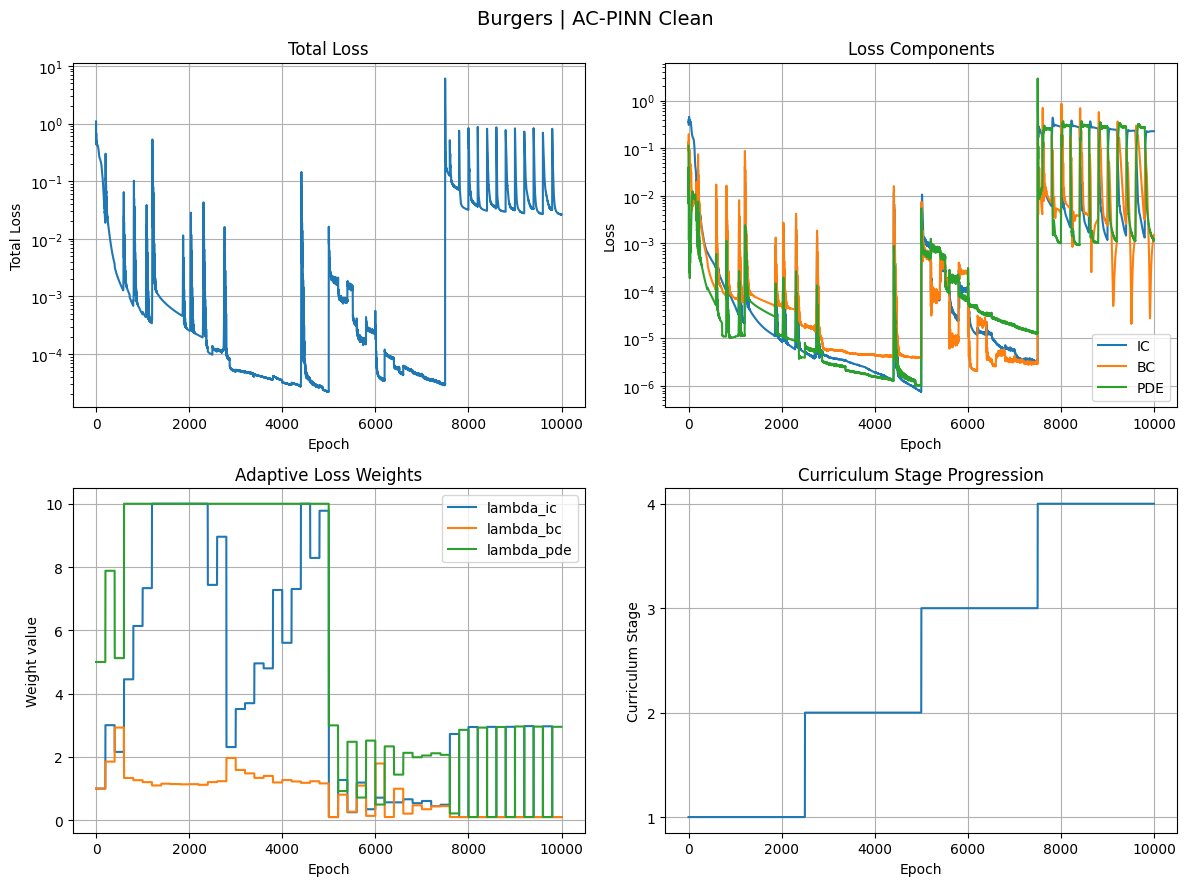

Saved: ../figures/burgers/acpinn_clean_training.png
Saved: ../figures/burgers/acpinn_clean_training.csv


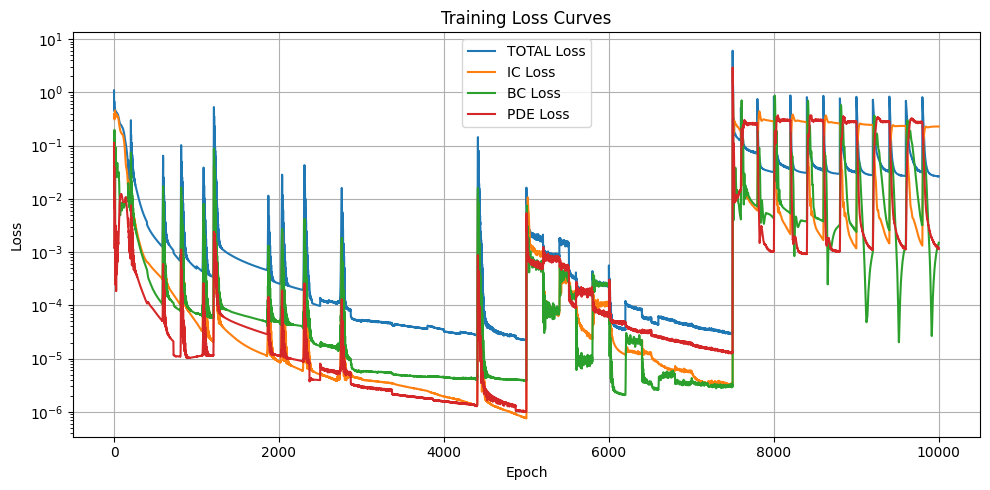

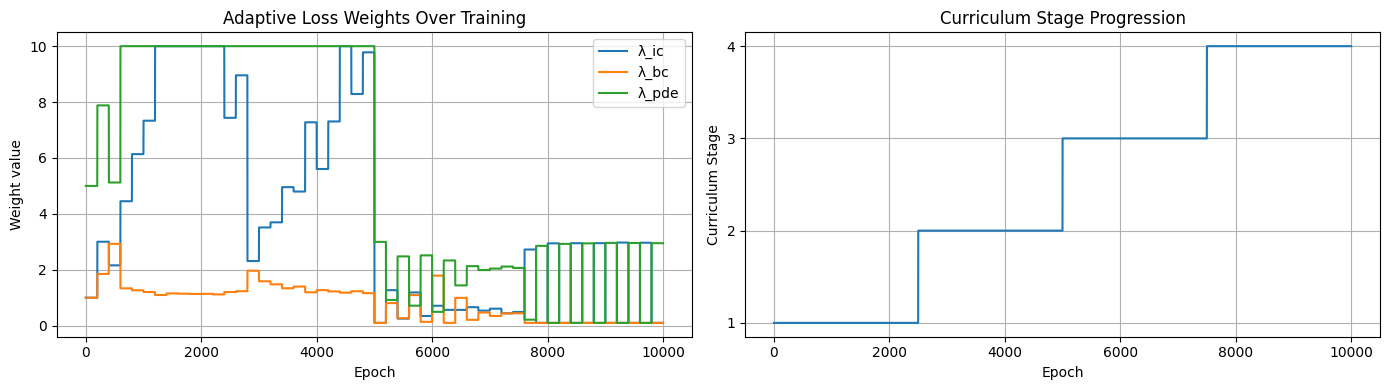

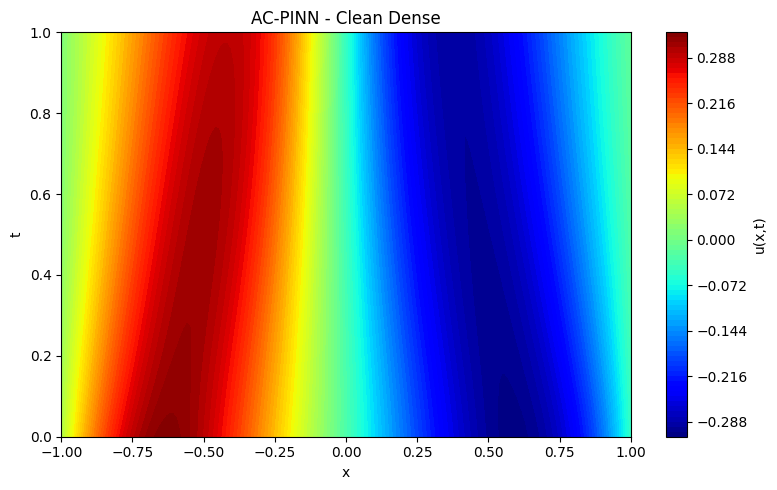

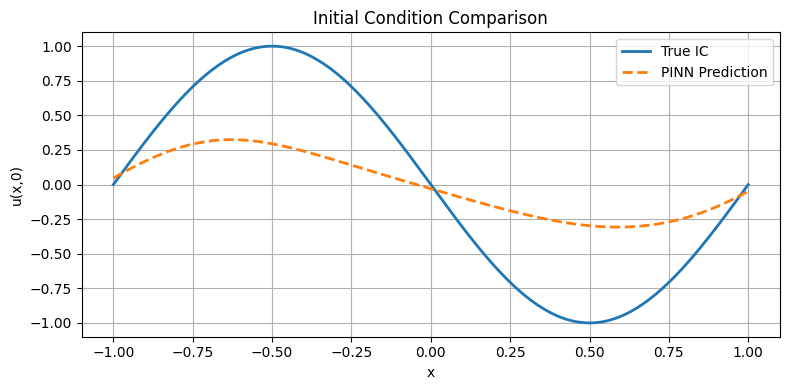

Saved: ../results/burgers/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Burgers | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS + 'ac_clean_history.npy')

## Section 6 - Experiment 4: AC-PINN, Noisy Sparse

[Burgers | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.526563 | IC: 0.461731 | BC: 0.061533 | PDE: 0.000660 | lam=(1.00,1.00,5.00)


[Burgers | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.061619 | IC: 0.006861 | BC: 0.018467 | PDE: 0.000067 | lam=(1.67,2.68,10.00)


[Burgers | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.049732 | IC: 0.004145 | BC: 0.016895 | PDE: 0.000127 | lam=(3.64,2.02,4.35)


[Burgers | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.041262 | IC: 0.003446 | BC: 0.016970 | PDE: 0.000121 | lam=(3.35,1.69,9.25)


[Burgers | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.035017 | IC: 0.002765 | BC: 0.015910 | PDE: 0.000032 | lam=(5.00,1.31,10.00)


...

[Burgers | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.034623 | IC: 0.002662 | BC: 0.014768 | PDE: 0.002724 | lam=(0.40,2.20,0.41)


[Burgers | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.033228 | IC: 0.002316 | BC: 0.014130 | PDE: 0.002745 | lam=(0.36,2.21,0.43)


[Burgers | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.160472 | IC: 0.072234 | BC: 0.020923 | PDE: 0.033292 | lam=(1.71,0.50,0.79)


[Burgers | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.583517 | IC: 0.003012 | BC: 0.020792 | PDE: 0.214009 | lam=(0.10,0.26,2.70)



AC-PINN training complete in 152.17s


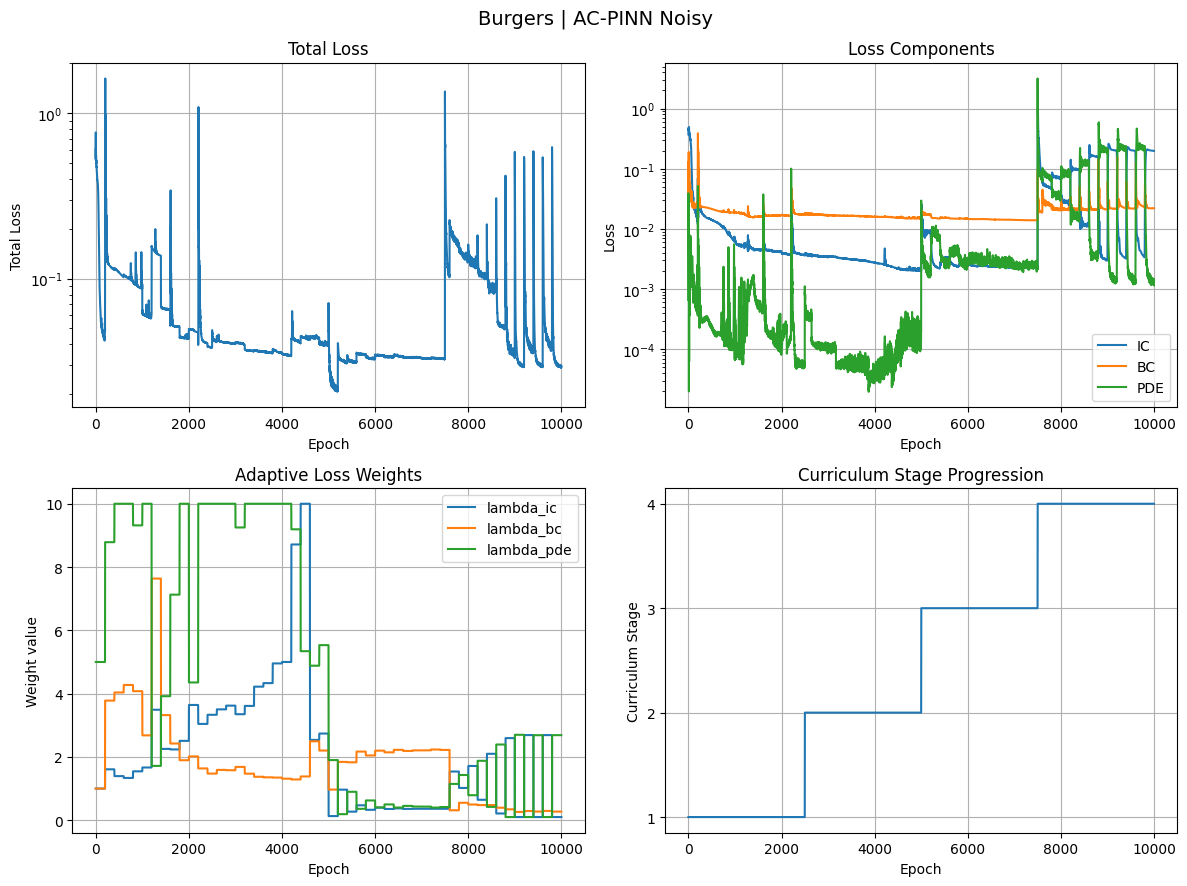

Saved: ../figures/burgers/acpinn_noisy_training.png
Saved: ../figures/burgers/acpinn_noisy_training.csv


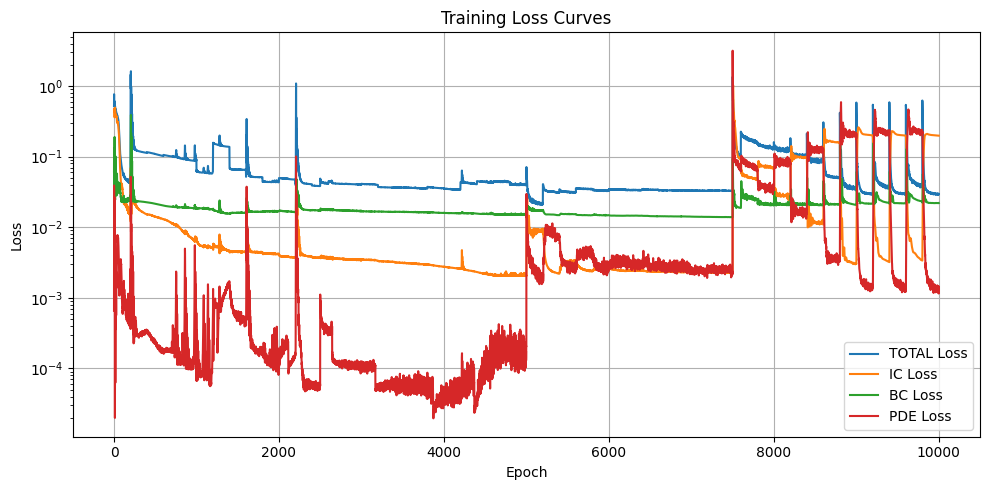

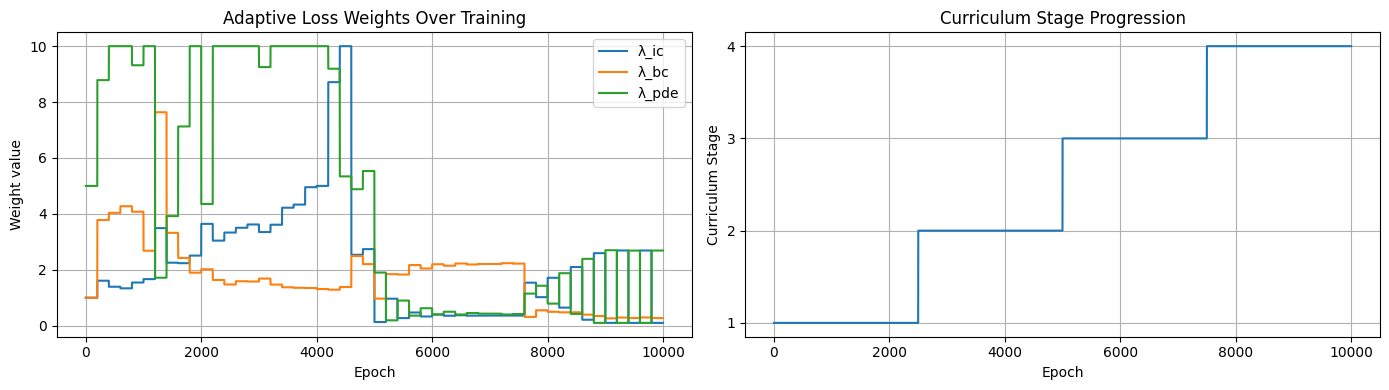

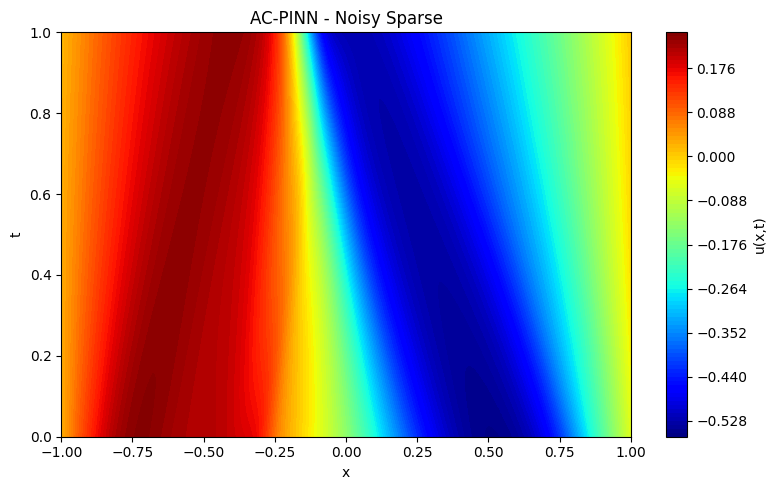

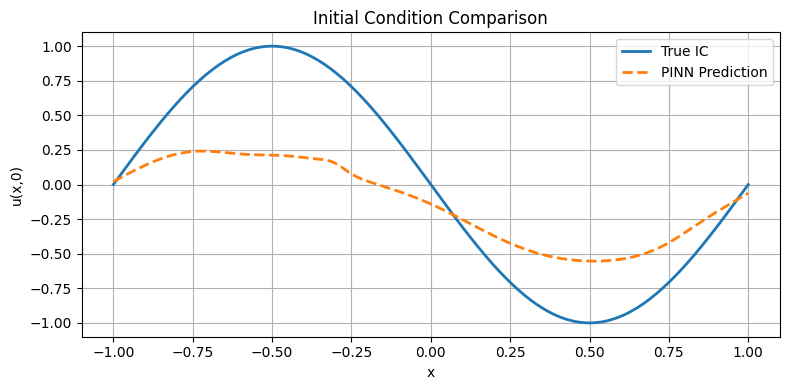

Saved: ../results/burgers/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Burgers | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
ac_noisy.plot_initial_condition_comparison(gen)
save_history(h_an, RESULTS + 'ac_noisy_history.npy')

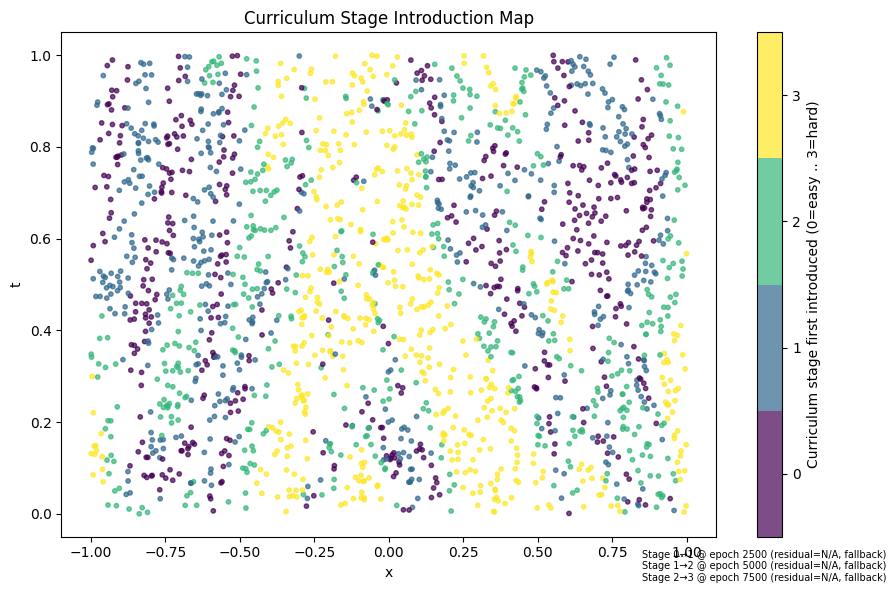

Saved: ../figures/burgers/curriculum_stages_noisy.png


In [8]:
ac_noisy.plot_curriculum_stages(
    h_an, data_noisy_sparse, FIGURES+'curriculum_stages_noisy.png'
)


## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.134953   1.238577   0.016328   0.082074
  Vanilla (noisy)             0.634876   2.002455   0.144422   0.386109
  AC-PINN (clean)             0.720397   0.968723   0.342156   0.438120
  AC-PINN (noisy)             0.694984   1.232810   0.304495   0.422664


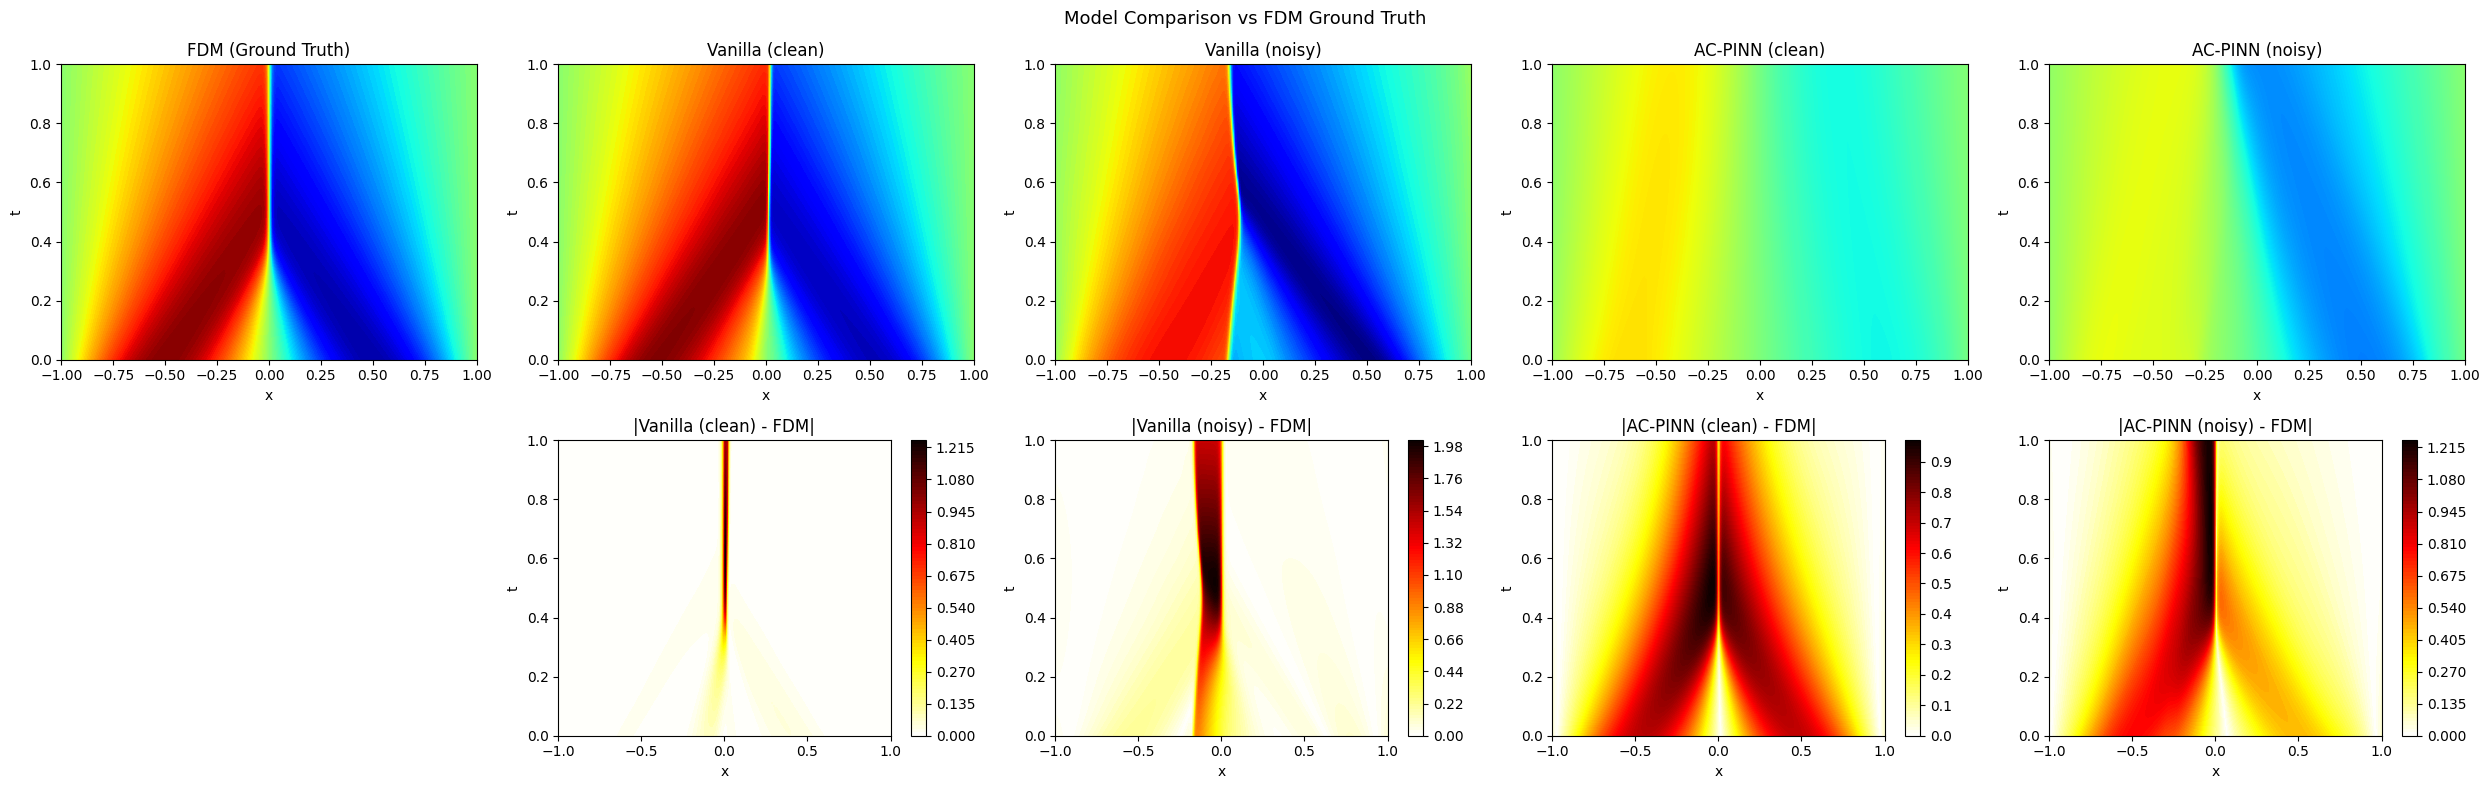

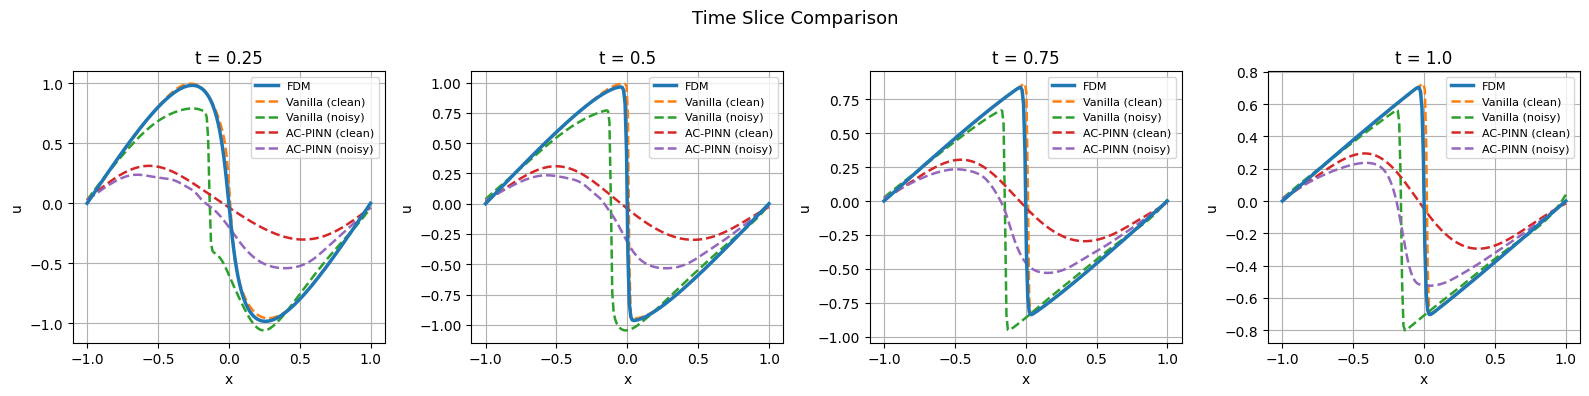

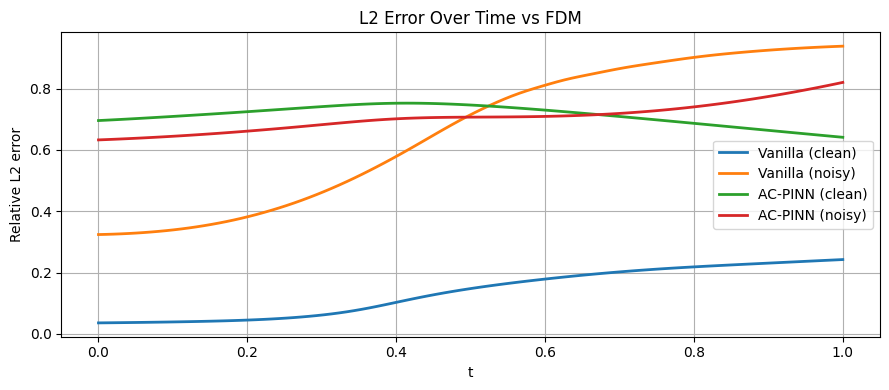

Saved: ../results/burgers/benchmark_metrics.npy
Burgers experiments complete. Results saved.


In [9]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)',  vanilla_clean)
bench.add('Vanilla (noisy)',  vanilla_noisy)
bench.add('AC-PINN (clean)',  ac_clean)
bench.add('AC-PINN (noisy)',  ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Burgers experiments complete. Results saved.')

## Section 8 - Noise Level Study (ε = 0.05, 0.1, 0.2)
AC-PINN vs Vanilla under increasing noise.

In [10]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- Noise level ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)

    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)

    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)

    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()

save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Noise study complete.')


--- Noise level ε=0.05 ---
[Epoch     0/5000] Total: 0.555864 | IC: 0.451479 | BC: 0.069787 | PDE: 0.006919


[Epoch  2500/5000] Total: 0.088580 | IC: 0.059954 | BC: 0.006424 | PDE: 0.004440



Training complete in 69.76s
[Epoch     0/5000] Stage 1/4 | Total: 0.802932 | IC: 0.676792 | BC: 0.041630 | PDE: 0.016902 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.142355 | IC: 0.001525 | BC: 0.005574 | PDE: 0.022109 | lam=(7.40,1.46,5.56)



AC-PINN training complete in 79.54s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.223049   1.603529   0.053116   0.135650
  AC-PINN ε=0.05              0.235411   0.714321   0.084299   0.143169

--- Noise level ε=0.1 ---
[Epoch     0/5000] Total: 1.039002 | IC: 0.714655 | BC: 0.097147 | PDE: 0.045440


...


AC-PINN training complete in 76.24s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.433437   1.600977   0.104598   0.263601
  AC-PINN ε=0.1               0.321960   0.883190   0.118701   0.195805

--- Noise level ε=0.2 ---
[Epoch     0/5000] Total: 1.185034 | IC: 0.513090 | BC: 0.143136 | PDE: 0.105762


[Epoch  2500/5000] Total: 0.133807 | IC: 0.073102 | BC: 0.052425 | PDE: 0.001656



Training complete in 70.25s
[Epoch     0/5000] Stage 1/4 | Total: 0.954444 | IC: 0.534564 | BC: 0.134191 | PDE: 0.057138 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.372130 | IC: 0.025173 | BC: 0.045225 | PDE: 0.011814 | lam=(7.81,1.27,10.00)



AC-PINN training complete in 79.70s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.568203   1.956780   0.142246   0.345561
  AC-PINN ε=0.2               0.327827   0.820625   0.125472   0.199373
Saved: ../results/burgers/noise_study_metrics.npy
Noise study complete.
